In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io.votable import parse_single_table

In [39]:
dpath = '../data/'
fpath = '../../figures/'

# Experiment with either querying in Gaia archive, then parsing votables such as this
# Or querying directly through astroquery.gaia
# Nevertheless, full Hipp. data ~50MB. Not too bad
table_xm = parse_single_table(dpath+'hipp_marrese19_xm.vot')
table_noxm = parse_single_table(dpath+'hipp_marrese19_noxm.vot')

## Planned for this Notebook
- Play around with the possibilities of votables and astroquery
- See if other Python packages can help with statistical analysis of Hipparcos data
    - e.g. let some kind of ML/SciPy function do a huge covariance analysis or something like that. Works better than just doing everything by eye
- Make new figures for IDA

## Figures
### Star Locations

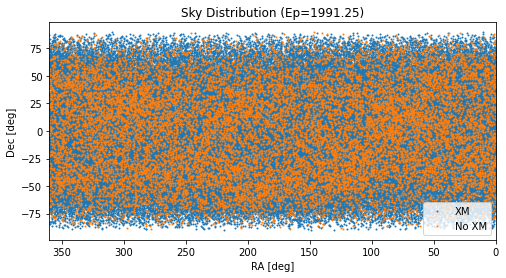

In [69]:
# RA vs. Dec
ra_xm = table_xm.array['ra']
de_xm = table_xm.array['dec']
ra_noxm = table_noxm.array['ra']
de_noxm = table_noxm.array['dec']

fig, ax = plt.subplots(1,1,figsize=(8,4))
ax.scatter(ra_xm, de_xm, s=1, label='XM')
ax.scatter(ra_noxm, de_noxm, s=1, label='No XM')

ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Sky Distribution (Ep=1991.25)")
ax.set_xlim(0, 360)
ax.invert_xaxis()

plt.legend(loc='lower right')
plt.savefig(fpath+'ida_skydist', bbox_inches='tight', transparent=True)
plt.show()

C:\Users\Rens\AppData\Local\Temp/ipykernel_3564/2213573942.py:6: RuntimeWarning: divide by zero encountered in log10
  ax.hist(np.log10(plx_xm), density=True, log=True, histtype='step', lw=4, label='XM')
C:\Users\Rens\AppData\Local\Temp/ipykernel_3564/2213573942.py:6: RuntimeWarning: invalid value encountered in log10
  ax.hist(np.log10(plx_xm), density=True, log=True, histtype='step', lw=4, label='XM')
C:\Users\Rens\AppData\Local\Temp/ipykernel_3564/2213573942.py:7: RuntimeWarning: divide by zero encountered in log10
  ax.hist(np.log10(plx_noxm), density=True, log=True, histtype='step', lw=4, label='No XM')
C:\Users\Rens\AppData\Local\Temp/ipykernel_3564/2213573942.py:7: RuntimeWarning: invalid value encountered in log10
  ax.hist(np.log10(plx_noxm), density=True, log=True, histtype='step', lw=4, label='No XM')


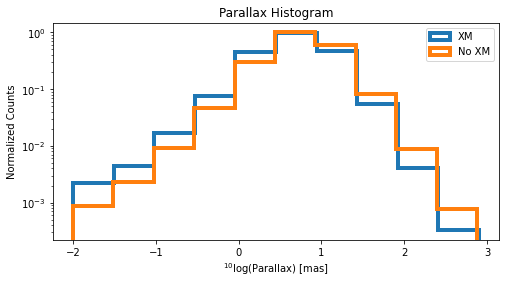

In [67]:
# Parallax
plx_xm = table_xm.array['plx']
plx_noxm = table_noxm.array['plx']

fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(np.log10(plx_xm), density=True, log=True, histtype='step', lw=4, label='XM')
ax.hist(np.log10(plx_noxm), density=True, log=True, histtype='step', lw=4, label='No XM')

ax.set_xlabel(r"$^{10}$log(Parallax) [mas]")
ax.set_ylabel("Normalized Counts")
ax.set_title("Parallax Histogram")

plt.legend()
plt.savefig(fpath+'ida_plx', bbox_inches='tight', transparent=True)
plt.show()

### Proper Motions

In [99]:
pmra_xm = table_xm.array['pm_ra']
pmde_xm = table_xm.array['pm_de']
epmra_xm = table_xm.array['e_pm_ra']
epmde_xm = table_xm.array['e_pm_de']

pmra_noxm = table_noxm.array['pm_ra']
pmde_noxm = table_noxm.array['pm_de']
epmra_noxm = table_noxm.array['e_pm_ra']
epmde_noxm = table_noxm.array['e_pm_de']

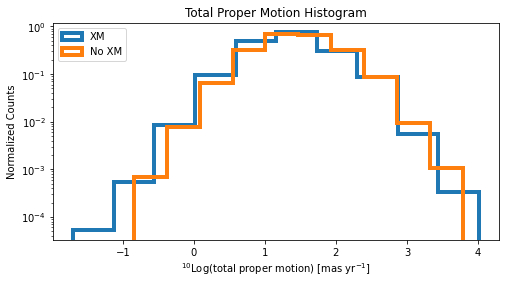

In [107]:
pm_xm = np.sqrt((pmra_xm**2) + (pmde_xm**2))
pm_noxm = np.sqrt((pmra_noxm**2) + (pmde_noxm**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(np.log10(pm_xm), density=True, log=True, histtype='step', lw=4, label='XM')
ax.hist(np.log10(pm_noxm), density=True, log=True, histtype='step', lw=4, label='No XM')

ax.set_xlabel(r"$^{10}$Log(total proper motion) [mas yr$^{-1}$]")
ax.set_ylabel("Normalized Counts")
ax.set_title("Total Proper Motion Histogram")

plt.legend()
plt.savefig(fpath+'total_pm', bbox_inches='tight', transparent=True)
plt.show()

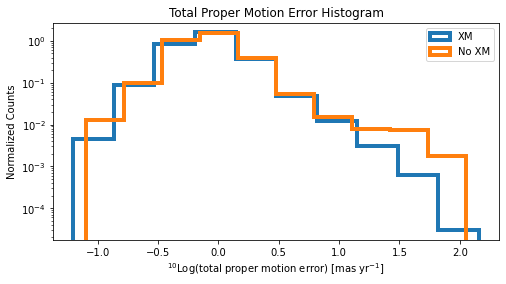

In [114]:
epm_xm = np.sqrt(((pmra_xm * epmra_xm)**2) + ((pmde_xm*epmde_xm)**2))/np.sqrt((pmra_xm**2) + (pmde_xm**2))
epm_noxm = np.sqrt(((pmra_noxm * epmra_noxm)**2) + ((pmde_noxm*epmde_noxm)**2))/np.sqrt((pmra_noxm**2) + (pmde_noxm**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(np.log10(epm_xm), density=True, log=True, histtype='step', lw=4, label='XM')
ax.hist(np.log10(epm_noxm), density=True, log=True, histtype='step', lw=4, label='No XM')

ax.set_xlabel(r"$^{10}$Log(total proper motion error) [mas yr$^{-1}$]")
ax.set_ylabel("Normalized Counts")
ax.set_title("Total Proper Motion Error Histogram")

plt.legend()
plt.savefig(fpath+'e_total_pm', bbox_inches='tight', transparent=True)
plt.show()

### Magnitudes & Colours

In [72]:
hp_xm = table_xm.array["hp_mag"]
b_xm = table_xm.array["btmag"]
v_xm = table_xm.array["vtmag"]
bv_xm = table_xm.array["b_v"]
vi_xm = table_xm.array["v_i"]

hp_noxm = table_noxm.array["hp_mag"]
b_noxm = table_noxm.array["btmag"]
v_noxm = table_noxm.array["vtmag"]
bv_noxm = table_noxm.array["b_v"]
vi_noxm = table_noxm.array["v_i"]

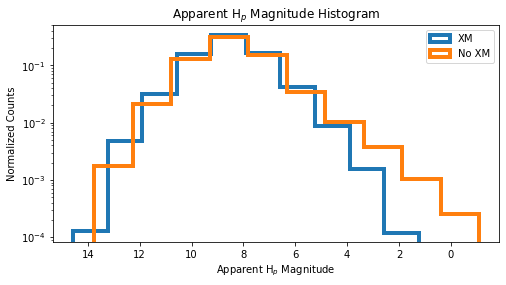

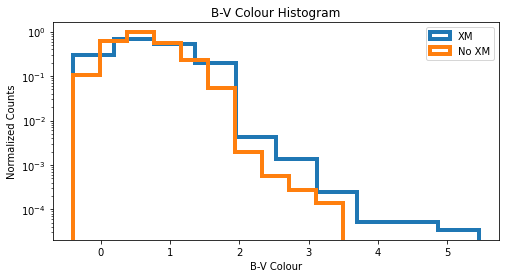

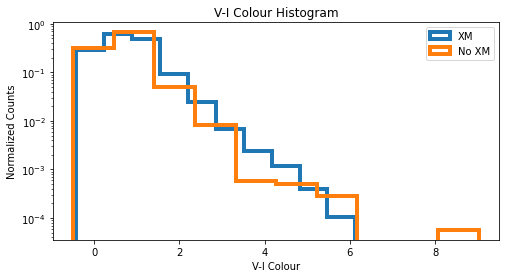

In [85]:
# Magnitude & Colour Histograms
sets = [[hp_xm, hp_noxm],[bv_xm, bv_noxm],[vi_xm, vi_noxm]]
labels = [r"Apparent H$_p$ Magnitude", "B-V Colour", "V-I Colour"]
save_name = ['hp', 'bv', 'vi']

for i in range(len(labels)):
    set_xm = sets[i][0]
    set_noxm = sets[i][1]

    fig, ax = plt.subplots(1,1, figsize=(8, 4))
    ax.hist(set_xm, density=True, log=True, histtype='step', lw=4, label='XM')
    ax.hist(set_noxm, density=True, log=True, histtype='step', lw=4, label='No XM')

    if 'Magnitude' in labels[i]:
        ax.invert_xaxis()

    ax.set_xlabel(labels[i])
    ax.set_ylabel("Normalized Counts")
    ax.set_title(labels[i]+" Histogram")

    plt.legend()
    plt.savefig(fpath+'ida_'+save_name[i], bbox_inches='tight', transparent=True)
    plt.show()

C:\Users\Rens\AppData\Local\Temp/ipykernel_3564/4294710965.py:2: RuntimeWarning: divide by zero encountered in log10
  abs_hp_xm = hp_xm + 5.*(np.log10(plx_xm/1e3) + 1.)
C:\Users\Rens\AppData\Local\Temp/ipykernel_3564/4294710965.py:2: RuntimeWarning: invalid value encountered in log10
  abs_hp_xm = hp_xm + 5.*(np.log10(plx_xm/1e3) + 1.)
C:\Users\Rens\AppData\Local\Temp/ipykernel_3564/4294710965.py:3: RuntimeWarning: divide by zero encountered in log10
  abs_hp_noxm = hp_noxm + 5.*(np.log10(plx_noxm/1e3) + 1.)
C:\Users\Rens\AppData\Local\Temp/ipykernel_3564/4294710965.py:3: RuntimeWarning: invalid value encountered in log10
  abs_hp_noxm = hp_noxm + 5.*(np.log10(plx_noxm/1e3) + 1.)


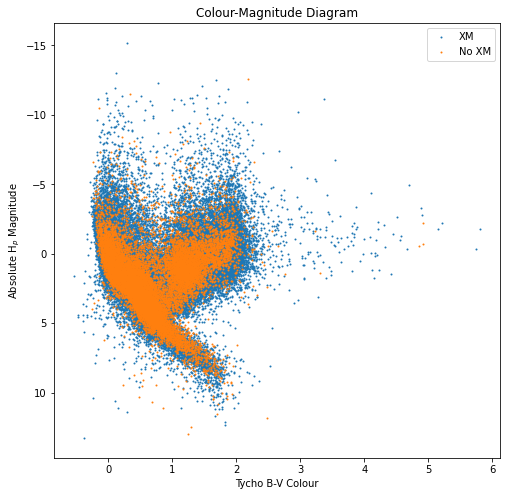

In [111]:
# Colour Magnitude Diagram
abs_hp_xm = hp_xm + 5.*(np.log10(plx_xm/1e3) + 1.)
abs_hp_noxm = hp_noxm + 5.*(np.log10(plx_noxm/1e3) + 1.)

tbv_xm = b_xm - v_xm
tbv_noxm = b_noxm - v_noxm

fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.scatter(tbv_xm, abs_hp_xm, s=1, label='XM')
ax.scatter(tbv_noxm, abs_hp_noxm, s=1, label='No XM')

ax.set_xlabel("Tycho B-V Colour")
ax.set_ylabel(r"Absolute H$_p$ Magnitude")
ax.set_title("Colour-Magnitude Diagram")
ax.invert_yaxis()

plt.legend()
plt.savefig(fpath+'ida_cmd', bbox_inches='tight', transparent=True)
plt.show()